In [ ]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
from PIL import Image

## Load dataset

In [ ]:
REPO_ID = "eturok-weizmann/vibration-data"
ds = load_dataset(REPO_ID, split="train")
print(f"{len(ds)} training samples, columns: {ds.column_names}")

63 training samples, columns: ['shifts_idx', 'overhead_image', 'x_position', 'y_position', 'experiment_config', 'fps', 'object']


In [4]:
# Load the model
model = build_sam3_image_model()
processor = Sam3Processor(model)

In [69]:
def segment_object(sample):
    """
    Returns:
        img         : (H, W, 3) uint8 ndarray — raw image
        crop_params : (x1, x2, y1, y2)
        cropped     : (H', W', 3) uint8 ndarray
        overlay     : (H', W', 4) float32 RGBA ndarray  (both masks combined)
        mask        : (H', W') BoolTensor               (both masks combined)
    """
    img = np.array(sample["overhead_image"].convert("RGB"))
    H, W = img.shape[:2]
    x1, x2 = int(W * 0.31), int(W * 0.62)
    y1, y2 = int(H * 0.25), H
    cropped = img[y1:y2, x1:x2]

    # Run model once at threshold=0 to get all candidates
    processor.set_confidence_threshold(0.0)
    state = processor.set_image(Image.fromarray(cropped))
    out = processor.set_text_prompt(state=state, prompt=sample["object"])

    # Pick top-2 by score
    n = len(out["scores"])
    k = min(2, n)
    if n > k:
        idx = out["scores"].topk(k).indices
        out["masks"]  = out["masks"][idx]
        out["boxes"]  = out["boxes"][idx]
        out["scores"] = out["scores"][idx]

    print(f"detections: {k}, scores: {out['scores'].tolist()}")

    mask = out["masks"][:, 0].any(dim=0)   # (H', W') BoolTensor

    overlay = np.zeros((*mask.shape, 4), dtype=np.float32)
    overlay[mask.cpu().numpy()] = (0.0, 0.8, 0.2, 0.5)

    return img, (x1, x2, y1, y2), cropped, overlay, mask


In [70]:
def plot_segment(sample, img, lines, cropped, overlay, mask):
    x1, x2, y1, y2 = lines
    fig, axes = plt.subplots(1, 4, figsize=(13, 5))

    axes[0].imshow(img)
    axes[0].axvline(x1, color="r"); axes[0].axvline(x2, color="r")
    axes[0].axhline(y1, color="r"); axes[0].axhline(y2 - 1, color="r")
    axes[0].set_title("Raw + crop lines", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(cropped)
    axes[1].set_title("Cropped", fontsize=12)
    axes[1].axis("off")

    axes[2].imshow(mask.cpu().numpy(), cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("Mask", fontsize=12)
    axes[2].axis("off")

    axes[3].imshow(cropped)
    axes[3].imshow(overlay)
    axes[3].set_title(f"Overlay — '{sample['object']}'", fontsize=12)
    axes[3].axis("off")

    plt.tight_layout()
    return fig

detections: 2, scores: [0.0865677148103714, 0.08626021444797516]


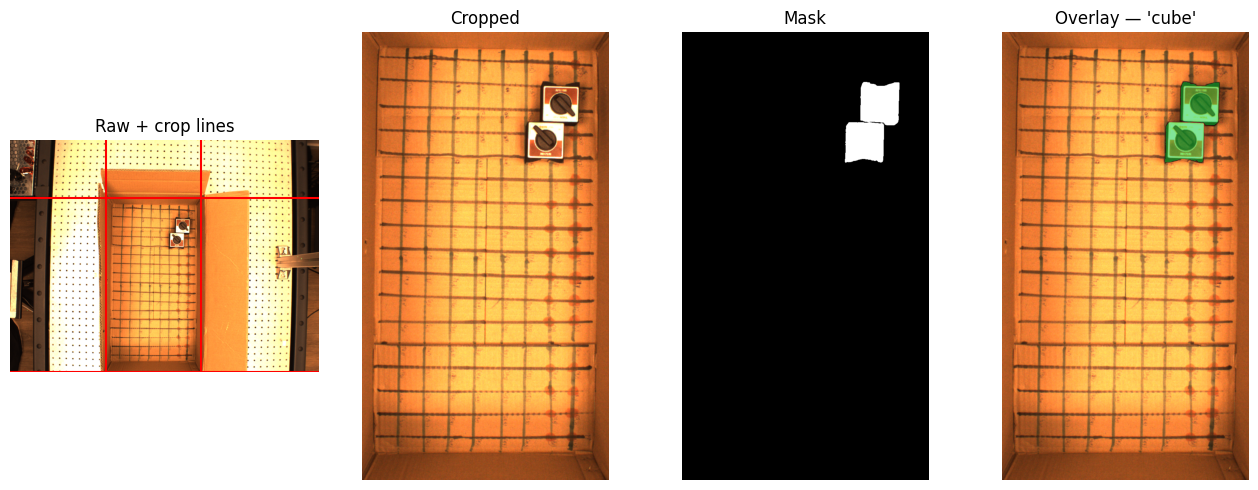

In [ ]:
for i in range(len(ds)):
    sample = ds[i]
    img, lines, cropped, overlay, mask = segment_object(sample)
    fig = plot_segment(sample, img, lines, cropped, overlay, mask)
    plt.show()